# Individual Task 2 - Case Study in Data science
Devarshi Patel (s4208864)

This notebook extends the exact Task 1 setup with:
1. Five-fold stratified cross-validation
2. Learning curves using F1-score
3. Credit Default fairness analysis using SEX
4. Exportable result tables for the Task 2 report

Datasets: bank-full.csv and default of credit card clients.xls.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

RANDOM_STATE = 42


In [2]:
# Locate datasets
bank_candidates = ["bank-full.csv", "/mnt/data/bank-full (1).csv", "/mnt/data/bank (1).csv"]
credit_candidates = ["default of credit card clients.xls", "/mnt/data/default of credit card clients (1).xls"]

bank_path = next((p for p in bank_candidates if os.path.exists(p)), None)
credit_path = next((p for p in credit_candidates if os.path.exists(p)), None)

if bank_path is None or credit_path is None:
    raise FileNotFoundError("Place bank-full.csv and the Credit Card Default .xls in the notebook directory.")

bank_df = pd.read_csv(bank_path, sep=";")
credit_df = pd.read_excel(credit_path, header=1)

print("Bank Marketing dataset:", bank_df.shape)
print("Credit Default dataset:", credit_df.shape)


Bank Marketing dataset: (45211, 17)
Credit Default dataset: (30000, 25)


In [3]:
# Bank Marketing – same core preprocessing as Task 1
bank = bank_df.copy()
if "duration" in bank.columns:
    bank = bank.drop(columns=["duration"])
bank["y"] = bank["y"].map({"no": 0, "yes": 1})

X_bank, y_bank = bank.drop(columns=["y"]), bank["y"]
X_bank_train, X_bank_test, y_bank_train, y_bank_test = train_test_split(
    X_bank, y_bank, test_size=0.20, stratify=y_bank, random_state=RANDOM_STATE
)

bank_num = X_bank_train.select_dtypes(include=["number"]).columns.tolist()
bank_cat = X_bank_train.select_dtypes(exclude=["number"]).columns.tolist()

bank_pre = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), bank_num),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), bank_cat)
])

bank_lr = Pipeline([("preprocessor", bank_pre),
                    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))])
bank_knn = Pipeline([("preprocessor", bank_pre),
                     ("model", KNeighborsClassifier(n_neighbors=5))])


In [4]:
# Credit Card Default – retain SEX separately for fairness analysis
credit = credit_df.copy()
credit = credit.loc[:, ~credit.columns.astype(str).str.startswith("Unnamed")]
credit.columns = [str(c).strip() for c in credit.columns]

target_candidates = ["default.payment.next.month", "default payment next month"]
target = next((c for c in target_candidates if c in credit.columns), credit.columns[-1])

y_credit = credit[target].astype(int)
sensitive_credit = credit["SEX"].copy()
X_credit = credit.drop(columns=[target])

X_credit_train, X_credit_test, y_credit_train, y_credit_test, sensitive_train, sensitive_test = train_test_split(
    X_credit, y_credit, sensitive_credit,
    test_size=0.20, stratify=y_credit, random_state=RANDOM_STATE
)

credit_num = X_credit_train.select_dtypes(include=["number"]).columns.tolist()
credit_cat = X_credit_train.select_dtypes(exclude=["number"]).columns.tolist()

credit_pre = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), credit_num),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), credit_cat)
])

credit_lr = Pipeline([("preprocessor", credit_pre),
                      ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))])
credit_knn = Pipeline([("preprocessor", credit_pre),
                       ("model", KNeighborsClassifier(n_neighbors=5))])


## Five-fold Stratified Cross-Validation

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy":"accuracy", "precision":"precision", "recall":"recall", "f1":"f1"}

def cv_result(model, X, y, dataset, name):
    r = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    row = {"Dataset": dataset, "Model": name}
    for m in scoring:
        row[f"Mean {m.title()}"] = r[f"test_{m}"].mean()
        row[f"Std {m.title()}"] = r[f"test_{m}"].std()
    return row

rows = [
    cv_result(bank_lr, X_bank_train, y_bank_train, "Bank Marketing", "Logistic Regression"),
    cv_result(bank_knn, X_bank_train, y_bank_train, "Bank Marketing", "kNN"),
    cv_result(credit_lr, X_credit_train, y_credit_train, "Credit Default", "Logistic Regression"),
    cv_result(credit_knn, X_credit_train, y_credit_train, "Credit Default", "kNN")
]
cv_results = pd.DataFrame(rows)
display(cv_results.round(4))


,Dataset,Model,Mean Accuracy,Std Accuracy,Mean Precision,Std Precision,Mean Recall,Std Recall,Mean F1,Std F1
0,Bank Marketing,Logistic Regression,0.7549,0.0055,0.2661,0.0040,0.6223,0.0092,0.3727,0.0032
1,Bank Marketing,kNN,0.8862,0.0026,0.5351,0.0301,0.2033,0.0181,0.2944,0.0227
2,Credit Default,Logistic Regression,0.6911,0.0107,0.3827,0.0122,0.6453,0.0155,0.4804,0.0125
3,Credit Default,kNN,0.7952,0.0040,0.5602,0.0152,0.3458,0.0068,0.4276,0.0085


## Learning Curves

F1-score is used because it balances precision and recall.


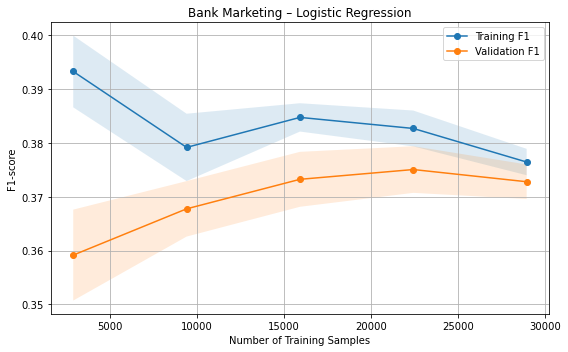

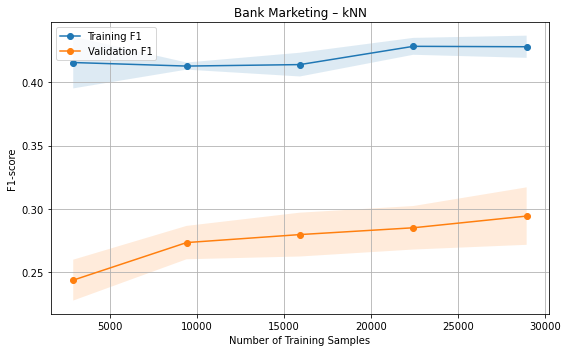

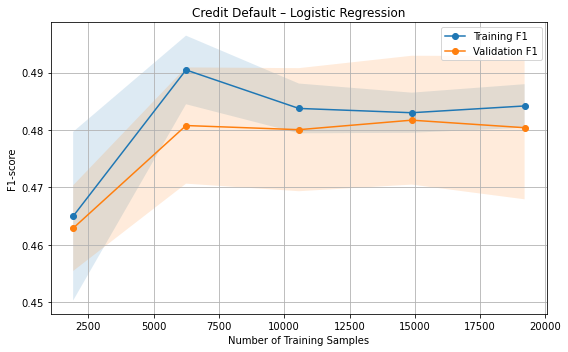

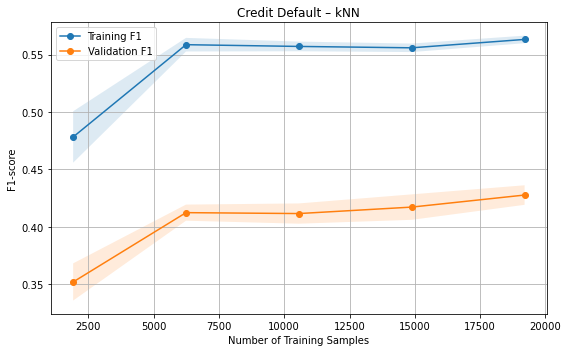

In [6]:
def learning_curve_analysis(model, X, y, title):
    sizes, train, valid = learning_curve(
        model, X, y, train_sizes=np.linspace(0.1, 1.0, 5),
        cv=cv, scoring="f1", n_jobs=-1
    )
    tm, ts = train.mean(axis=1), train.std(axis=1)
    vm, vs = valid.mean(axis=1), valid.std(axis=1)

    plt.figure(figsize=(8,5))
    plt.plot(sizes, tm, marker="o", label="Training F1")
    plt.plot(sizes, vm, marker="o", label="Validation F1")
    plt.fill_between(sizes, tm-ts, tm+ts, alpha=.15)
    plt.fill_between(sizes, vm-vs, vm+vs, alpha=.15)
    plt.xlabel("Number of Training Samples")
    plt.ylabel("F1-score")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return pd.DataFrame({
        "Training Samples": sizes,
        "Training F1 Mean": tm,
        "Training F1 Std": ts,
        "Validation F1 Mean": vm,
        "Validation F1 Std": vs
    })

learning_results = {
    "Bank Logistic Regression": learning_curve_analysis(
        bank_lr, X_bank_train, y_bank_train, "Bank Marketing – Logistic Regression"),
    "Bank kNN": learning_curve_analysis(
        bank_knn, X_bank_train, y_bank_train, "Bank Marketing – kNN"),
    "Credit Logistic Regression": learning_curve_analysis(
        credit_lr, X_credit_train, y_credit_train, "Credit Default – Logistic Regression"),
    "Credit kNN": learning_curve_analysis(
        credit_knn, X_credit_train, y_credit_train, "Credit Default – kNN")
}


## Final 20% Holdout Evaluation

In [7]:
def evaluate(model, Xtr, ytr, Xte, yte, dataset, name):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    return {
        "Dataset": dataset, "Model": name,
        "Accuracy": accuracy_score(yte, pred),
        "Precision": precision_score(yte, pred, zero_division=0),
        "Recall": recall_score(yte, pred, zero_division=0),
        "F1": f1_score(yte, pred, zero_division=0)
    }, pred

specs = [
    ("Bank Marketing","Logistic Regression",bank_lr,X_bank_train,y_bank_train,X_bank_test,y_bank_test),
    ("Bank Marketing","kNN",bank_knn,X_bank_train,y_bank_train,X_bank_test,y_bank_test),
    ("Credit Default","Logistic Regression",credit_lr,X_credit_train,y_credit_train,X_credit_test,y_credit_test),
    ("Credit Default","kNN",credit_knn,X_credit_train,y_credit_train,X_credit_test,y_credit_test)
]
rows, predictions = [], {}
for dataset, name, model, Xtr, ytr, Xte, yte in specs:
    row, pred = evaluate(model,Xtr,ytr,Xte,yte,dataset,name)
    rows.append(row)
    predictions[(dataset,name)] = pred

holdout_results = pd.DataFrame(rows)
display(holdout_results.round(4))


,Dataset,Model,Accuracy,Precision,Recall,F1
0,Bank Marketing,Logistic Regression,0.7552,0.2666,0.6238,0.3735
1,Bank Marketing,kNN,0.8874,0.5529,0.1975,0.2911
2,Credit Default,Logistic Regression,0.6813,0.3690,0.6209,0.4629
3,Credit Default,kNN,0.7935,0.5530,0.3459,0.4256


## Fairness Analysis – Credit Card Default

Sensitive attribute: `SEX`.

The analysis reports group-level accuracy, precision, recall, F1 and selection rate, plus demographic parity difference/ratio and equalized-odds difference.


In [8]:
def fairness_report(y_true, y_pred, sensitive):
    d = pd.DataFrame({"y_true":np.asarray(y_true),
                      "y_pred":np.asarray(y_pred),
                      "group":np.asarray(sensitive)})
    rows, rates = [], []

    for g in sorted(d["group"].unique()):
        x = d[d["group"] == g]
        tn, fp, fn, tp = confusion_matrix(x.y_true, x.y_pred, labels=[0,1]).ravel()
        tpr = tp/(tp+fn) if tp+fn else np.nan
        fpr = fp/(fp+tn) if fp+tn else np.nan
        rows.append({
            "Group":g, "N":len(x),
            "Selection Rate":x.y_pred.mean(),
            "Accuracy":accuracy_score(x.y_true,x.y_pred),
            "Precision":precision_score(x.y_true,x.y_pred,zero_division=0),
            "Recall":recall_score(x.y_true,x.y_pred,zero_division=0),
            "F1":f1_score(x.y_true,x.y_pred,zero_division=0)
        })
        rates.append({"Group":g,"TPR":tpr,"FPR":fpr})

    groups = pd.DataFrame(rows)
    rates = pd.DataFrame(rates)
    sr = groups["Selection Rate"]
    summary = pd.DataFrame([{
        "Demographic Parity Difference":sr.max()-sr.min(),
        "Demographic Parity Ratio":sr.min()/sr.max() if sr.max()!=0 else np.nan,
        "Equalized Odds Difference":max(
            rates.TPR.max()-rates.TPR.min(),
            rates.FPR.max()-rates.FPR.min()
        )
    }])
    return groups, rates, summary

fairness = {}
for name in ["Logistic Regression","kNN"]:
    fairness[name] = fairness_report(
        y_credit_test,
        predictions[("Credit Default",name)],
        sensitive_test
    )
    print("\n", name)
    display(fairness[name][0].round(4))
    display(fairness[name][1].round(4))
    display(fairness[name][2].round(4))



 Logistic Regression


,Group,N,Selection Rate,Accuracy,Precision,Recall,F1
0,1,2402,0.4542,0.6270,0.3465,0.6738,0.4576
1,2,3598,0.3174,0.7176,0.3905,0.5822,0.4675


,Group,TPR,FPR
0,1,0.6738,0.3873
1,2,0.5822,0.2458


,Demographic Parity Difference,Demographic Parity Ratio,Equalized Odds Difference
0,0.1368,0.6988,0.1415



 kNN


,Group,N,Selection Rate,Accuracy,Precision,Recall,F1
0,1,2402,0.1515,0.7789,0.5412,0.3512,0.4259
1,2,3598,0.1295,0.8032,0.5622,0.3420,0.4253


,Group,TPR,FPR
0,1,0.3512,0.0907
1,2,0.3420,0.0720


,Demographic Parity Difference,Demographic Parity Ratio,Equalized Odds Difference
0,0.022,0.8547,0.0187


## Optional Fairlearn verification

If Fairlearn is installed, this provides the same analysis using `MetricFrame`. If it is unavailable, the transparent manual calculations above remain usable for the report.


In [9]:
try:
    from fairlearn.metrics import (
        MetricFrame, selection_rate,
        demographic_parity_difference,
        demographic_parity_ratio,
        equalized_odds_difference
    )
    metrics = {
        "accuracy": accuracy_score,
        "precision": lambda y,p: precision_score(y,p,zero_division=0),
        "recall": lambda y,p: recall_score(y,p,zero_division=0),
        "f1": lambda y,p: f1_score(y,p,zero_division=0),
        "selection_rate": selection_rate
    }
    for name in ["Logistic Regression","kNN"]:
        pred = predictions[("Credit Default",name)]
        mf = MetricFrame(metrics=metrics, y_true=y_credit_test,
                         y_pred=pred, sensitive_features=sensitive_test)
        print(name)
        display(mf.by_group.round(4))
        print("DP difference:", demographic_parity_difference(
            y_credit_test,pred,sensitive_features=sensitive_test))
        print("DP ratio:", demographic_parity_ratio(
            y_credit_test,pred,sensitive_features=sensitive_test))
        print("EO difference:", equalized_odds_difference(
            y_credit_test,pred,sensitive_features=sensitive_test))
except ImportError:
    print("Fairlearn is not installed. Manual fairness calculations above are available.")


Fairlearn is not installed. Manual fairness calculations above are available.


## Save outputs

The CSV files created here can be retained as evidence for the Task 2 appendix.


In [10]:
cv_results.to_csv("task2_cross_validation_results.csv", index=False)
holdout_results.to_csv("task2_holdout_results.csv", index=False)

for name, (groups, rates, summary) in fairness.items():
    safe = name.lower().replace(" ","_")
    groups.to_csv(f"task2_fairness_{safe}_groups.csv", index=False)
    rates.to_csv(f"task2_fairness_{safe}_rates.csv", index=False)
    summary.to_csv(f"task2_fairness_{safe}_summary.csv", index=False)

for name, df in learning_results.items():
    safe = name.lower().replace(" ","_")
    df.to_csv(f"task2_learning_curve_{safe}.csv", index=False)

print("Task 2 outputs saved.")


Task 2 outputs saved.
